<div align="right">
АС-23-05, Тищенко Кирилл, Вариант №97
</div>

# Лабораторная работа №2 "Методы одномерной минимизации, использующие информацию о производных целевой функции"

$$f(x) = e^x - \frac{1}{3}x^3 + 2x \to \min, \quad x \in [-2,5, -1].$$

In [2]:
def f(x):
    return np.exp(x) - (1/3)*(x**3) + 2*x

def df(x):
    return np.exp(x) - x ** 2 + 2

def ddf(x):
    return np.exp(x) - x * 2

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar

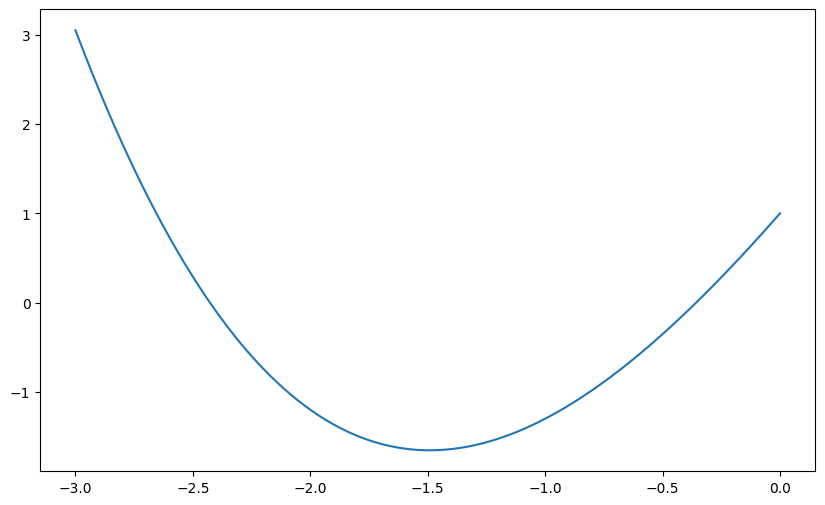

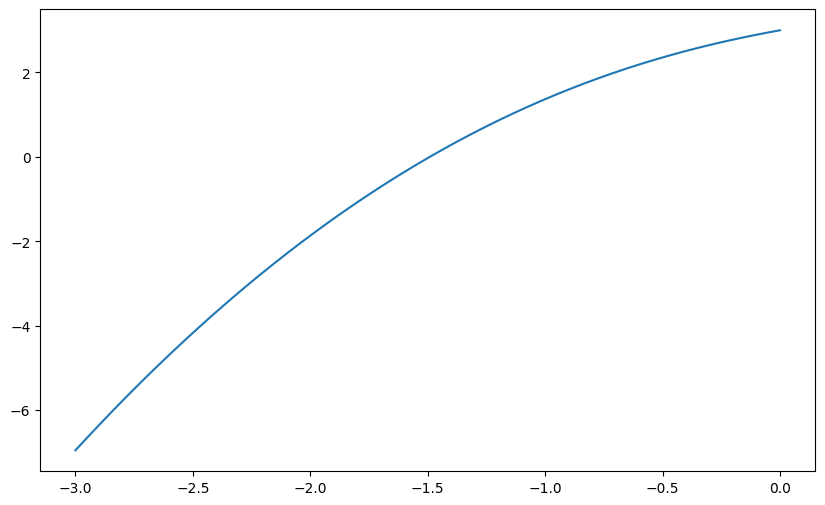

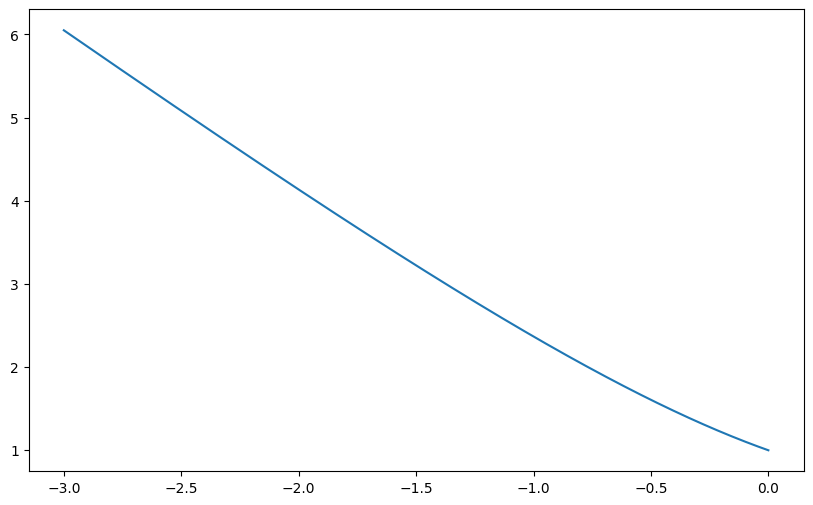

In [4]:
x = np.linspace(-3, 0, 400)
y1 = f(x)
y2 = df(x)
y3 = ddf(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y1)

plt.figure(figsize=(10, 6))
plt.plot(x, y2)

plt.figure(figsize=(10, 6))
plt.plot(x, y3)

## Пакетный метод

In [5]:
res = minimize_scalar(f, bounds=(-2.5, -1), method='bounded')
x_min_scipy = res.x
y_min_scipy = f(x_min_scipy)

print(f"Точка минимума x: {x_min_scipy:.4f}")
print(f"Минимальное значение f(x): {y_min_scipy:.4f}")

Точка минимума x: -1.4916
Минимальное значение f(x): -1.6520


## Метод средней точки

In [6]:
def midpoint(f = f, df = df, left = -2.5, right = -1, eps=1e-4):
    iteration = 1
    
    while right - left > eps:
        midpoint = (left + right) / 2
        
        if abs(df(midpoint)) < eps:
            return f"{midpoint:.4f}", iteration
            
        elif df(midpoint) > 0:
            right = midpoint
            iteration += 1
            
        elif df(midpoint) < 0:
            left = midpoint
            iteration += 1

    midpoint = (left + right) / 2
    return f"{midpoint:.4f}", iteration

In [7]:
def visualize_midpoint(f=f, df=df, left=-2.5, right=-1, eps=1e-4, iters=10):
    x = np.linspace(left - 0.5, right + 0.5, 400)
    y = f(x)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(x, y, label="f(x)", alpha=0.4)

    for i in range(iters):
        midpoint = (left + right) / 2
        
        ax.axvspan(left, right, alpha=0.12)
        ax.axvline(midpoint, linestyle="--")
        ax.plot(midpoint, f(midpoint), "o")

        if abs(df(midpoint)) < eps:
            break
        elif df(midpoint) > 0:
            right = midpoint
        else:
            left = midpoint

    ax.set_title("Метод средней точки (первые 10 итераций)")
    ax.grid(True)
    ax.legend()

    plt.show()

Точка минимума x: -1.4916
Минимальное значение f(x): -1.6520
За: 13 итераций


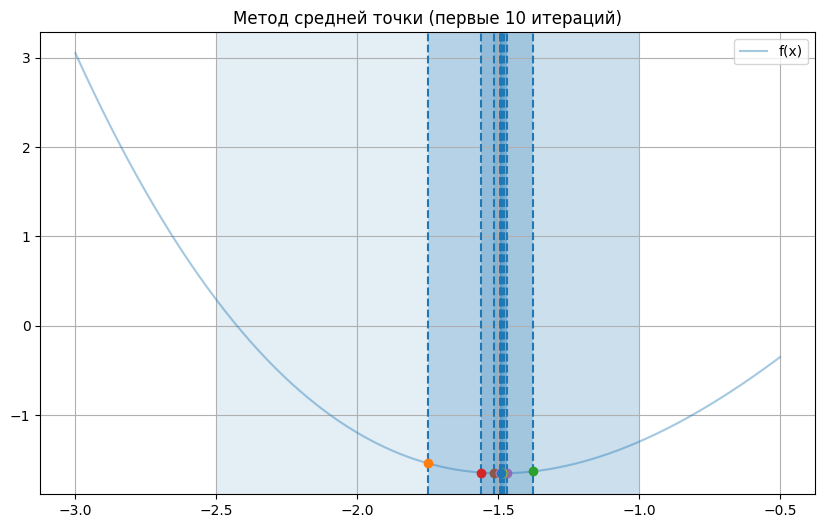

In [8]:
print(f"Точка минимума x: {midpoint(f, df)[0]}")
print(f"Минимальное значение f(x): {f(float(midpoint(f, df)[0])):.4f}")
print(f"За: {midpoint(f, df)[1]} итераций")
visualize_midpoint()

## Метод Ньютона

In [36]:
def newton(f = f, df = df, ddf = ddf, x = 1, eps=1e-4):
    iteration = 0
    while abs(df(x) / ddf(x)) >= eps:
        x = x - df(x) / ddf(x)
        iteration += 1
    return f"{x:.4f}", iteration

In [10]:
def visualize_newton(f=f, df=df, ddf=ddf, x0=-1.49, eps=1e-4, iters=10):
    x = np.linspace(x0-2, x0+2, 400)
    y = df(x)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(x, y, label="f(x)", alpha=0.4)

    xk = x0

    for i in range(iters):
        yk = df(xk)
        slope = ddf(xk)

        t = np.linspace(xk-1, xk+1, 100)
        tangent = yk + slope*(t-xk)
        ax.plot(t, tangent, "--", alpha=0.6)

        ax.plot(xk, yk, "ro")

        step = df(xk)/ddf(xk)
        if abs(step) < eps:
            break

        x_next = xk - step

        ax.vlines(x_next, min(y), f(x_next), linestyles="dotted", alpha=0.6)

        xk = x_next

    ax.set_title("Метод Ньютона (первые 10 итераций)")
    ax.grid(True)
    ax.legend()
    plt.show()

Точка минимума x: -1.4917
Минимальное значение f(x): 1.6697
Итераций: 5


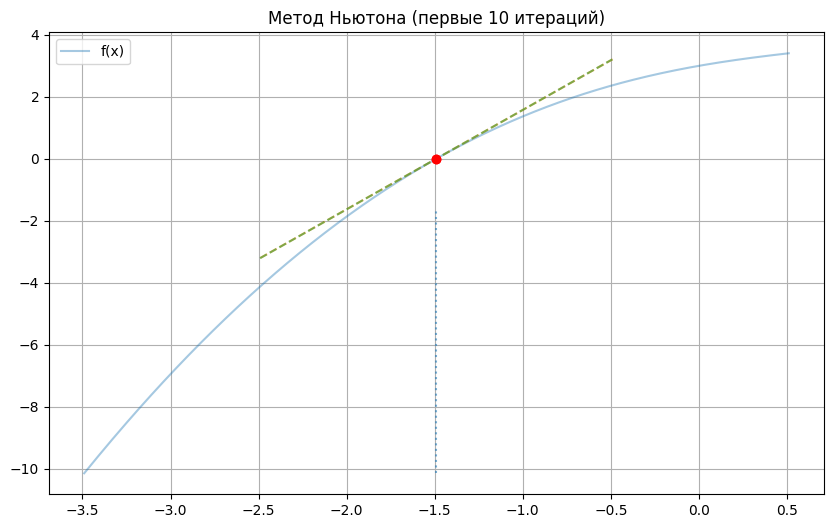

In [37]:
print(f"Точка минимума x: {newton()[0]}")
print(f"Минимальное значение f(x): {f(float(newton()[0])):.4f}")
print(f"Итераций: {newton()[1]}")
visualize_newton()

## Метод Ньютона-Рафсона

In [34]:
def newton_raphson(f = f, df = df, ddf = ddf, x = -1.49, eps=1e-4):
    iteration = 1
    while abs(df(x) / ddf(x)) >= eps:
        tau = (df(x) ** 2) / ((df(x) ** 2) + (df(x - df(x) / ddf(x)) ** 2))
        x = x - tau * (df(x) / ddf(x))
        iteration += 1
    return f"{x:.4f}", iteration

In [13]:
def visualize_newton_raphson(f=f, df=df, ddf=ddf, x0=-1, eps=1e-4, max_iters=10):
    x_range = np.linspace(x0-2, x0+2, 400)
    y_range = df(x_range)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(x_range, y_range, label="df(x)", alpha=0.4)

    xk = x0
    for i in range(max_iters):
        yk = df(xk)
        slope = ddf(xk)

        t = np.linspace(xk-1, xk+1, 100)
        tangent = yk + slope*(t-xk)
        ax.plot(t, tangent, "--", alpha=0.6)

        ax.plot(xk, yk, "ro")

        step = df(xk)/ddf(xk)
        tau = (df(xk)**2) / ((df(xk)**2) + (df(xk - step)**2))
        x_next = xk - tau*step

        ax.vlines(x_next, min(y_range), f(x_next), linestyles="dotted", alpha=0.6)

        if abs(x_next - xk) < eps:
            break

        xk = x_next

    ax.set_title("Метод Ньютона–Рафсона (первые 10 итераций)")
    ax.grid(True)
    ax.legend()
    plt.show()

Точка минимума x: -1.4916
Минимальное значение f(x): -1.6520
Итераций: 2


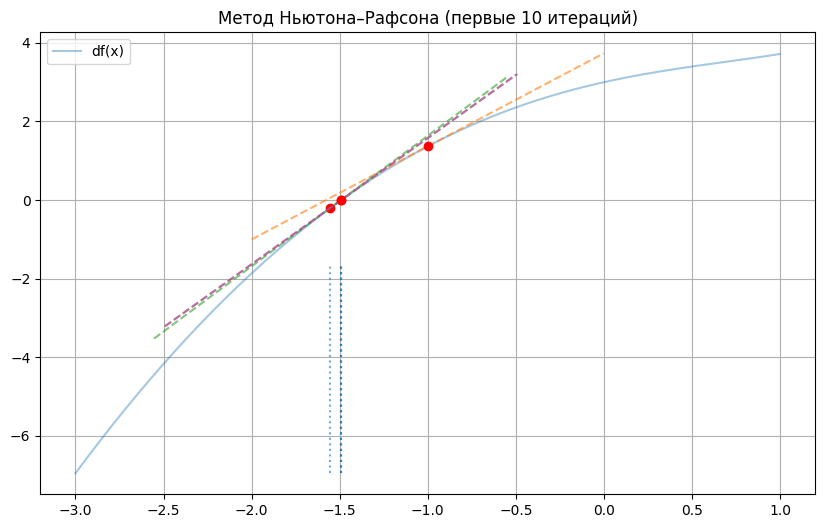

In [14]:
print(f"Точка минимума x: {newton_raphson()[0]}")
print(f"Минимальное значение f(x): {f(float(newton_raphson()[0])):.4f}")
print(f"Итераций: {newton_raphson()[1]}")
visualize_newton_raphson()

| Метод | x_min| f(x_min) |
| :--- | :--- | :--- |
| Пакетный scipy | -1.4916 | -1.6520 |
| Средней точки | -1.4915 | -1.6520 |
| Метод Ньютона | -1.4916 | -1.6520 |
| Метод Ньютона-Рафсона | -1.4916 | -1.6520 |

In [15]:
def f2(x):
    return x * np.arctan(x) - 0.5 * np.log(1 + x ** 2)

def df2(x):
    return np.arctan(x)

def ddf2(x):
    return 1 / (1 + x**2)

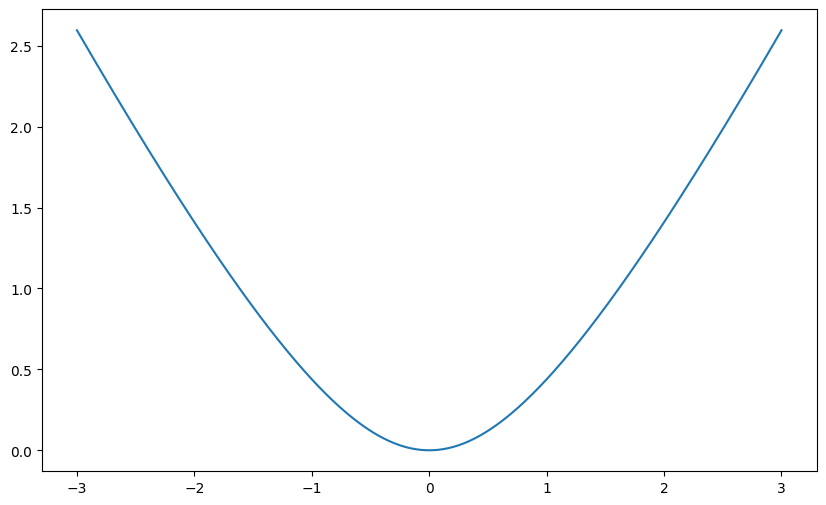

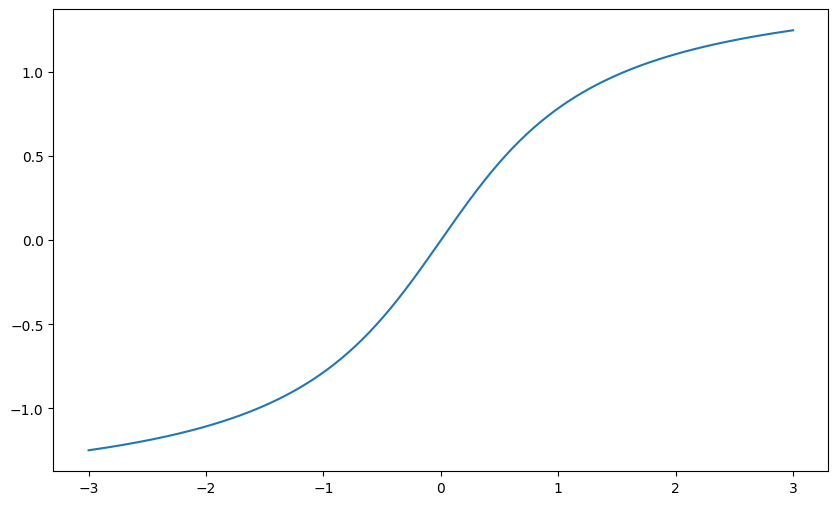

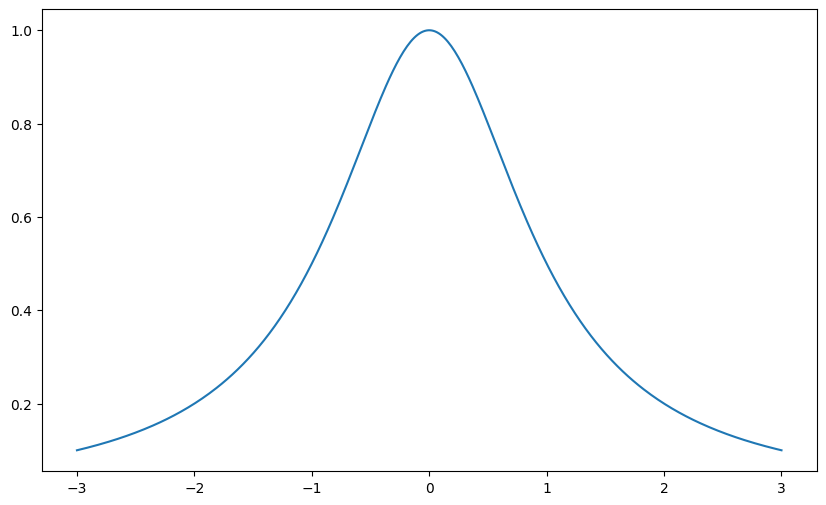

In [16]:
x = np.linspace(-3, 3, 400)
y1 = f2(x)
y2 = df2(x)
y3 = ddf2(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y1)

plt.figure(figsize=(10, 6))
plt.plot(x, y2)

plt.figure(figsize=(10, 6))
plt.plot(x, y3)

## Пакетный метод

In [17]:
res = minimize_scalar(f2, bounds=(-3, 3), method='bounded')
x_min_scipy = res.x
y_min_scipy = f2(x_min_scipy)

print(f"Точка минимума x: {x_min_scipy:.4f}")
print(f"Минимальное значение f(x): {y_min_scipy:.4f}")

Точка минимума x: 0.0000
Минимальное значение f(x): 0.0000


## Метод средней точки

Точка минимума x: -0.0000
Минимальное значение f(x): 0.0000
За: 15 итераций


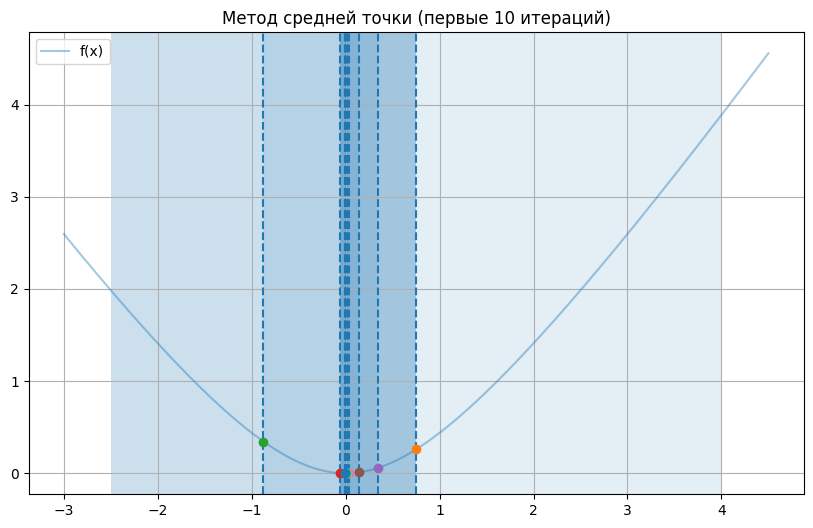

In [18]:
print(f"Точка минимума x: {midpoint(f = f2, df = df2, right = 4)[0]}")
print(f"Минимальное значение f(x): {f2(float(midpoint(f = f2, df = df2, right = 4)[0])):.4f}")
print(f"За: {midpoint(f = f2, df = df2, right = 4)[1]} итераций")
visualize_midpoint(f = f2, df = df2, right = 4)

## Метод Ньютона

Точка минимума x: -0.9376
Минимальное значение f(x): 0.4777
Итераций: 1


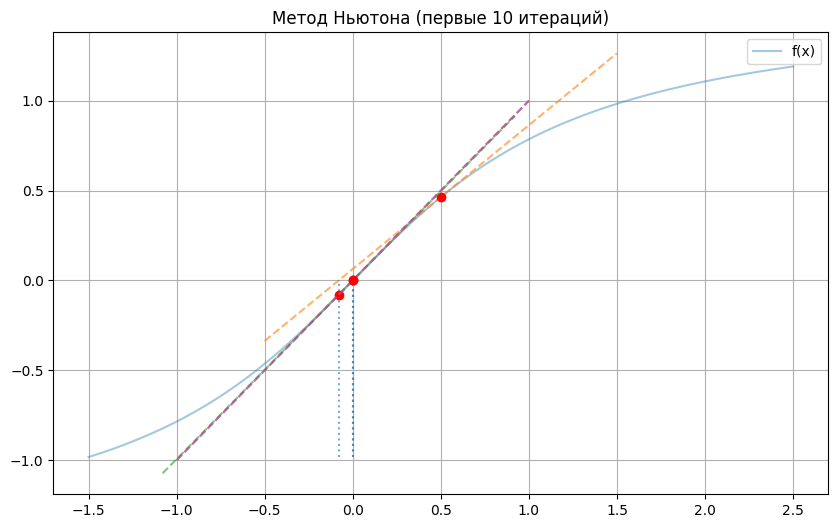

In [29]:
print(f"Точка минимума x: {newton(f = f2, df = df2, ddf = ddf2, x = 1.2)[0]}")
print(f"Минимальное значение f(x): {f(float(newton(f = f2, df = df2, ddf = ddf2, x = 1.2)[0])):.4f}")
print(f"Итераций: {newton(f = f2, df = df2, ddf = ddf2, x = 1.2)[1]}")
visualize_newton(f = f2, df = df2, ddf = ddf2, x0 = 0.5)

## Метод Ньютона-Рафсона

Точка минимума x: -0.0000
Минимальное значение f(x): 1.0000
Итераций: 2


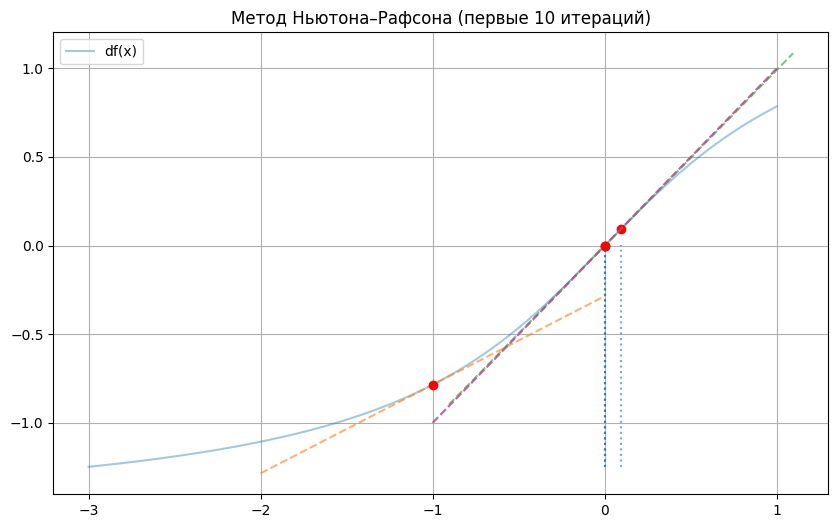

In [20]:
print(f"Точка минимума x: {newton_raphson(f = f2, df = df2, ddf = ddf2, x = 0.04)[0]}")
print(f"Минимальное значение f(x): {f(float(newton_raphson(f = f2, df = df2, ddf = ddf2, x = 0.04)[0])):.4f}")
print(f"Итераций: {newton_raphson(f = f2, df = df2, ddf = ddf2, x = 0.04)[1]}")
visualize_newton_raphson(f = f2, df = df2, ddf = ddf2)

| Метод | x_min| f(x_min) |
| :--- | :--- | :--- |
| Пакетный scipy | 0.0000 | 0.0000 |
| Средней точки | 0.0000 | 0.0000 |
| Метод Ньютона | 0.0000 | 0.0000 |
| Метод Ньютона-Рафсона | 0.0000 | 0.0000 |

In [35]:
min_start_nr = np.inf
min_start_new = np.inf
max_start_nr = -np.inf
max_start_new = -np.inf

for start in range(-30000, 30000):
    start = start / 10000
    if abs(float(newton_raphson(f = f2, df = df2, ddf = ddf2, x = start)[0])) < 1e-4:
        min_start_nr = min(min_start_nr, start)
        max_start_nr = max(max_start_nr, start)
    if abs(float(newton(f = f2, df = df2, ddf = ddf2, x = start)[0])) < 1e-4:
        min_start_new = min(min_start_new, start)
        max_start_new = max(max_start_new, start)

print(f"Границы начального приближения для метода Ньютона: [{min_start_new}, {max_start_new}]")
print(f"Границы начального приближения для метода Ньютона-Рафсона: [{min_start_nr}, {max_start_nr}]")

C:\Users\Кирилл\AppData\Local\Temp\ipykernel_19068\3606803913.py:8: RuntimeWarning: overflow encountered in scalar power
  return 1 / (1 + x**2)
C:\Users\Кирилл\AppData\Local\Temp\ipykernel_19068\1645862746.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  while abs(df(x) / ddf(x)) >= eps:
C:\Users\Кирилл\AppData\Local\Temp\ipykernel_19068\1645862746.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  x = x - df(x) / ddf(x)
C:\Users\Кирилл\AppData\Local\Temp\ipykernel_19068\1645862746.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  x = x - df(x) / ddf(x)
C:\Users\Кирилл\AppData\Local\Temp\ipykernel_19068\1645862746.py:3: RuntimeWarning: overflow encountered in scalar divide
  while abs(df(x) / ddf(x)) >= eps:
C:\Users\Кирилл\AppData\Local\Temp\ipykernel_19068\1645862746.py:4: RuntimeWarning: overflow encountered in scalar divide
  x = x - df(x) / ddf(x)


Границы начального приближения для метода Ньютона: [-1.3917, 1.3917]
Границы начального приближения для метода Ньютона-Рафсона: [-3.0, 2.9999]
